Generando señal de vibración de un motor con rodamiento dañado...
Matriz acústica lista: 100 ventanas con 120 lecturas cada una.
------------------------------------------------------------
Extrayendo 15 firmas acústicas usando el 100% de la CPU...
Motor analizado en 4.72 segundos.

 DIAGNÓSTICO DEL ALGORITMO (VIBRACIONES INDUSTRIALES)
 1. Fidelidad (Error Puro):         475.4795
 2. Castigo de Esparcidad (L1):     316.9411
------------------------------------------------------------
 -> COSTO TOTAL DEL SPARSE CODER:   792.4206

Generando la radiografía de los átomos mecánicos...


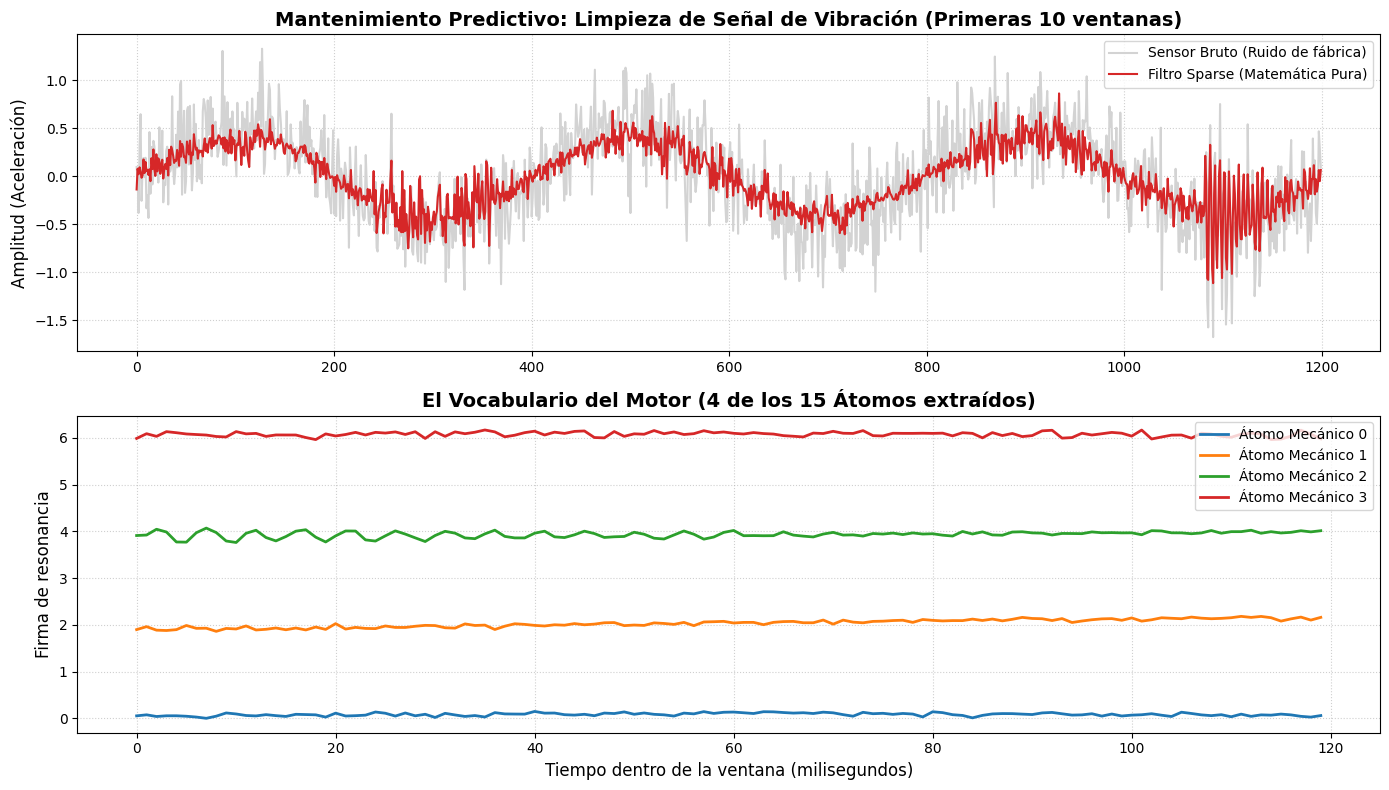

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.decomposition import DictionaryLearning

# ==========================================
# 1) SIMULACIÓN DEL SENSOR INDUSTRIAL (12.000 Hz)
# ==========================================
print("Generando señal de vibración de un motor con rodamiento dañado...")
fs = 12000  # Frecuencia de muestreo (12 kHz)
t = np.arange(0, 1.0, 1/fs)  # 1 segundo de grabación (12.000 puntos)

# A) Ruido normal del eje girando (Baja frecuencia)
eje_sano = 0.5 * np.sin(2 * np.pi * 30 * t) 

# B) Impactos del rodamiento roto (Alta frecuencia que decae)
frec_impacto = 10  # Golpea 10 veces por segundo
impactos = np.zeros_like(t)
impactos[::int(fs/frec_impacto)] = 1.0

# Creamos la onda de resonancia del metal (el "clack" agudo)
tiempo_res = np.arange(0, 0.02, 1/fs)
resonancia = np.exp(-300 * tiempo_res) * np.sin(2 * np.pi * 2500 * tiempo_res)

# Unimos todo y le sumamos ruido blanco de la fábrica
ruido_fabrica = np.random.normal(0, 0.3, len(t))
senal_vibracion = eje_sano + np.convolve(impactos, resonancia, mode='same') + ruido_fabrica

# ==========================================
# 2) PREPARACIÓN DE LA MATRIZ (VENTANEO)
# ==========================================
# Cortamos el segundo de audio en 100 trozos (ventanas) de 120 puntos cada uno
longitud_ventana = 120
num_ventanas = len(senal_vibracion) // longitud_ventana

# Nuestra matriz X: 100 ejemplos, 120 dimensiones físicas (milisegundos)
X_vibracion = senal_vibracion[:num_ventanas * longitud_ventana].reshape(num_ventanas, longitud_ventana)

print(f"Matriz acústica lista: {X_vibracion.shape[0]} ventanas con {X_vibracion.shape[1]} lecturas cada una.")
print("-" * 60)

# ==========================================
# 3) SPARSE CODING EXTREMO (TODOS LOS NÚCLEOS)
# ==========================================
n_atoms = 15
lambda_param = 1.0

print(f"Extrayendo {n_atoms} firmas acústicas usando el 100% de la CPU...")
inicio_tiempo = time.time()

dict_learner = DictionaryLearning(
    n_components=n_atoms, 
    alpha=lambda_param, 
    transform_algorithm='lasso_lars', 
    random_state=42,
    max_iter=1000,
    n_jobs=-1  # ¡MÁXIMA POTENCIA DEL MAC M1!
)

# Aprende el diccionario de vibraciones
sparse_representation = dict_learner.fit_transform(X_vibracion)
dictionary_atoms = dict_learner.components_

tiempo_total = time.time() - inicio_tiempo
print(f"Motor analizado en {tiempo_total:.2f} segundos.")

# ==========================================
# 4) AUDITORÍA MATEMÁTICA EXACTA
# ==========================================
X_reconstruido = np.dot(sparse_representation, dictionary_atoms)

# Fidelidad (Suma de cuadrados pura, sin raíces)
error_fidelidad = 0.5 * np.sum((X_vibracion - X_reconstruido) ** 2)
# Castigo por activación (Norma L1)
penalizacion_L1 = lambda_param * np.sum(np.abs(sparse_representation))
costo_total = error_fidelidad + penalizacion_L1

print("\n" + "="*60)
print(" DIAGNÓSTICO DEL ALGORITMO (VIBRACIONES INDUSTRIALES)")
print("="*60)
print(f" 1. Fidelidad (Error Puro):         {error_fidelidad:.4f}")
print(f" 2. Castigo de Esparcidad (L1):     {penalizacion_L1:.4f}")
print("-" * 60)
print(f" -> COSTO TOTAL DEL SPARSE CODER:   {costo_total:.4f}")
print("="*60 + "\n")

# ==========================================
# 5) VISUALIZACIÓN DE LAS FIRMAS ACÚSTICAS (LOS "ÁTOMOS")
# ==========================================
print("Generando la radiografía de los átomos mecánicos...")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Gráfica 1: La señal ruidosa vs La reconstrucción limpia
ax1.plot(X_vibracion.flatten()[:1200], color='lightgray', label='Sensor Bruto (Ruido de fábrica)')
ax1.plot(X_reconstruido.flatten()[:1200], color='tab:red', linewidth=1.5, label='Filtro Sparse (Matemática Pura)')
ax1.set_title('Mantenimiento Predictivo: Limpieza de Señal de Vibración (Primeras 10 ventanas)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Amplitud (Aceleración)', fontsize=12)
ax1.legend(loc="upper right")
ax1.grid(True, linestyle=':', alpha=0.6)



# Gráfica 2: Los Átomos aprendidos
for i in range(4): # Mostramos solo los 4 primeros átomos para no saturar
    desplazamiento = i * 2 # Los separamos visualmente
    ax2.plot(dictionary_atoms[i] + desplazamiento, linewidth=2, label=f'Átomo Mecánico {i}')

ax2.set_title(f'El Vocabulario del Motor (4 de los {n_atoms} Átomos extraídos)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Tiempo dentro de la ventana (milisegundos)', fontsize=12)
ax2.set_ylabel('Firma de resonancia', fontsize=12)
ax2.legend(loc="upper right")
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

Cargando el archivo de vibración original del disco duro...
¡Éxito! Señal real cargada. Total de lecturas: 121265 puntos a 12kHz.
------------------------------------------------------------
Matriz de entrenamiento lista: 606 ventanas de 200 dimensiones.
------------------------------------------------------------
Extrayendo 30 átomos mecánicos usando TODOS LOS NÚCLEOS...
Entrenamiento completado en 68.40 segundos.

 DIAGNÓSTICO EXACTO DEL SPARSE CODER (CWRU REAL)
 1. Fidelidad (Error Cuadrático Puro): 22272.1734
 2. Castigo de Esparcidad (L1):        12374.9322
------------------------------------------------------------
 -> COSTO TOTAL DEL ALGORITMO:         34647.1056
 -> Nivel de Esparcidad:               60.75% de ceros absolutos

Generando panel de análisis físico...


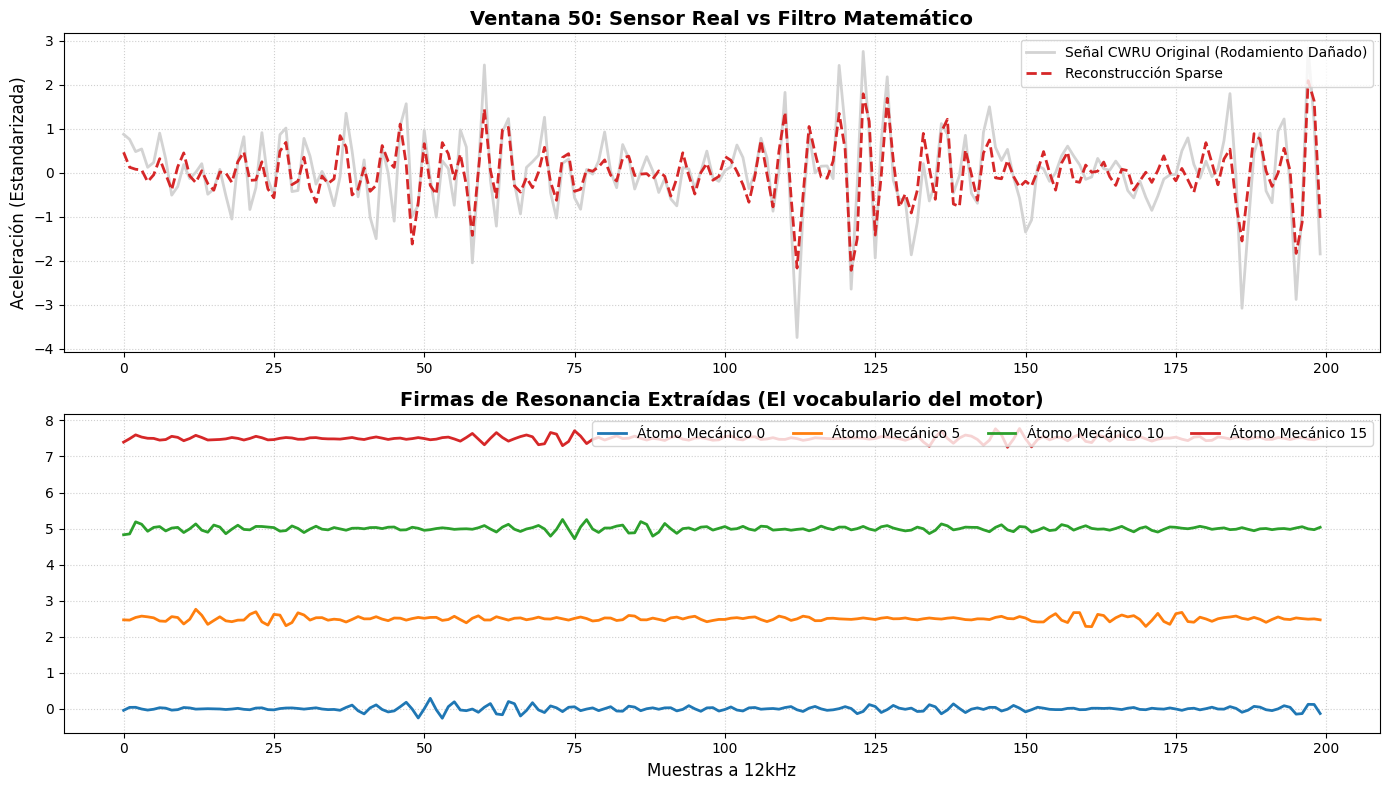

In [4]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import time
import sys
from sklearn.decomposition import DictionaryLearning
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1) LECTURA DEL ARCHIVO LOCAL CWRU (.mat)
# ==========================================
print("Cargando el archivo de vibración original del disco duro...")

# IMPORTANTE: Cambia "105.mat" si tu archivo tiene otro nombre
archivo_local = "105.mat" 

try:
    mat_data = scipy.io.loadmat(archivo_local)
except FileNotFoundError:
    print(f"\n[ERROR] No encuentro el archivo '{archivo_local}'.")
    print("Asegúrate de que está metido exactamente en la misma carpeta que este script.")
    sys.exit()

# Buscamos automáticamente la clave del sensor "Drive End" (DE_time)
clave_sensor = [key for key in mat_data.keys() if 'DE_time' in key][0]
senal_cruda = mat_data[clave_sensor].flatten()

print(f"¡Éxito! Señal real cargada. Total de lecturas: {len(senal_cruda)} puntos a 12kHz.")
print("-" * 60)

# ==========================================
# 2) PREPARACIÓN DE LA MATRIZ MATEMÁTICA
# ==========================================
# Cortamos la señal en ventanas de 200 puntos (unos 16 milisegundos de audio por ventana)
longitud_ventana = 200
num_ventanas = len(senal_cruda) // longitud_ventana

X_vibracion = senal_cruda[:num_ventanas * longitud_ventana].reshape(num_ventanas, longitud_ventana)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_vibracion)

print(f"Matriz de entrenamiento lista: {X_scaled.shape[0]} ventanas de {X_scaled.shape[1]} dimensiones.")
print("-" * 60)

# ==========================================
# 3) SPARSE CODING (MÁXIMA POTENCIA DE CPU)
# ==========================================
n_atoms = 30
lambda_param = 1.0

print(f"Extrayendo {n_atoms} átomos mecánicos usando TODOS LOS NÚCLEOS...")
inicio_tiempo = time.time()

dict_learner = DictionaryLearning(
    n_components=n_atoms, 
    alpha=lambda_param, 
    transform_algorithm='lasso_lars', 
    random_state=42,
    max_iter=1000,
    n_jobs=-1  # ¡Todo el procesador trabajando en paralelo!
)

sparse_representation = dict_learner.fit_transform(X_scaled)
dictionary_atoms = dict_learner.components_

print(f"Entrenamiento completado en {time.time() - inicio_tiempo:.2f} segundos.")

# ==========================================
# 4) AUDITORÍA DE LA FUNCIÓN OBJETIVO EXACTA
# ==========================================
X_reconstruido = np.dot(sparse_representation, dictionary_atoms)

# Matemáticas puras: Costo exacto al cuadrado (Sin aplicar raíces)
error_fidelidad = 0.5 * np.sum((X_scaled - X_reconstruido) ** 2)
penalizacion_L1 = lambda_param * np.sum(np.abs(sparse_representation))
costo_total = error_fidelidad + penalizacion_L1

ceros_exactos = np.sum(np.abs(sparse_representation) < 1e-5)
esparcidad_pct = (ceros_exactos / sparse_representation.size) * 100

print("\n" + "="*60)
print(" DIAGNÓSTICO EXACTO DEL SPARSE CODER (CWRU REAL)")
print("="*60)
print(f" 1. Fidelidad (Error Cuadrático Puro): {error_fidelidad:.4f}")
print(f" 2. Castigo de Esparcidad (L1):        {penalizacion_L1:.4f}")
print("-" * 60)
print(f" -> COSTO TOTAL DEL ALGORITMO:         {costo_total:.4f}")
print(f" -> Nivel de Esparcidad:               {esparcidad_pct:.2f}% de ceros absolutos")
print("="*60 + "\n")

# ==========================================
# 5) VISUALIZACIÓN DE INGENIERÍA
# ==========================================
print("Generando panel de análisis físico...")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Gráfica 1: Reconstrucción
ventana_idx = 50 # Escogemos una ventana aleatoria para verla
ax1.plot(X_scaled[ventana_idx], color='lightgray', linewidth=2, label='Señal CWRU Original (Rodamiento Dañado)')
ax1.plot(X_reconstruido[ventana_idx], color='tab:red', linewidth=2, linestyle='--', label='Reconstrucción Sparse')

ax1.set_title(f'Ventana {ventana_idx}: Sensor Real vs Filtro Matemático', fontsize=14, fontweight='bold')
ax1.set_ylabel('Aceleración (Estandarizada)', fontsize=12)
ax1.legend(loc="upper right")
ax1.grid(True, linestyle=':', alpha=0.6)

# Gráfica 2: Los Átomos
indices_atomos = [0, 5, 10, 15]
colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for idx, color in zip(indices_atomos, colores):
    ax2.plot(dictionary_atoms[idx] + (idx * 0.5), color=color, linewidth=2, label=f'Átomo Mecánico {idx}')

ax2.set_title(f'Firmas de Resonancia Extraídas (El vocabulario del motor)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Muestras a 12kHz', fontsize=12)
ax2.legend(loc="upper right", ncol=4)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

1. Creando la firma acústica de un motor 100% SANO...
2. Cargando tu archivo CWRU real (Motor ROTO)...

3. Entrenando 30 átomos con el motor SANO (Usando todos los núcleos)...
   Listo en 59.91 segundos.

4. Obligando al diccionario Sano a reconstruir el motor Roto...

 ALARMA DE MANTENIMIENTO PREDICTIVO (DETECCIÓN DE ANOMALÍAS)
 -> Error Exacto en máquina SANA:   9859.1594
 -> Error Exacto en máquina ROTA:   321619.7165
------------------------------------------------------------
 ¡ALERTA! El error matemático se ha multiplicado por 32.62x



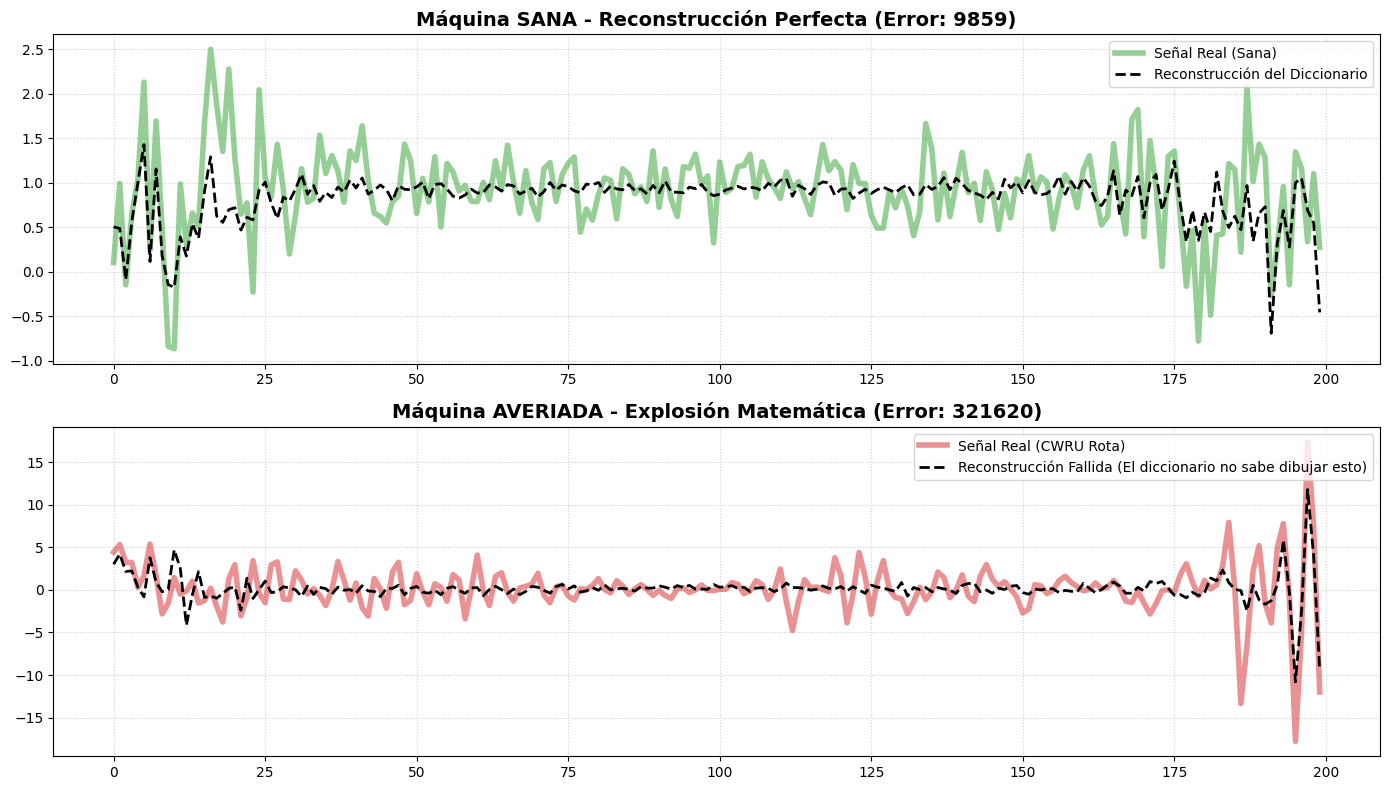

In [5]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import time
import sys
from sklearn.decomposition import DictionaryLearning
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1) EL MOTOR SANO (LÍNEA BASE)
# ==========================================
print("1. Creando la firma acústica de un motor 100% SANO...")
fs = 12000
t_sano = np.arange(0, 10.0, 1/fs) # 10 segundos de audio
# Un motor sano gira suavemente a 30Hz con un poco de ruido blanco de fondo
senal_sana = 0.2 * np.sin(2 * np.pi * 30 * t_sano) + np.random.normal(0, 0.05, len(t_sano))

longitud_ventana = 200
num_ventanas_sana = len(senal_sana) // longitud_ventana
X_sano = senal_sana[:num_ventanas_sana * longitud_ventana].reshape(num_ventanas_sana, longitud_ventana)

# ==========================================
# 2) EL MOTOR ROTO (TU ARCHIVO CWRU REAL)
# ==========================================
print("2. Cargando tu archivo CWRU real (Motor ROTO)...")
archivo_local = "105.mat" 
try:
    mat_data = scipy.io.loadmat(archivo_local)
except FileNotFoundError:
    print(f"\n[ERROR] No encuentro el '{archivo_local}'.")
    sys.exit()

clave_sensor = [key for key in mat_data.keys() if 'DE_time' in key][0]
senal_rota = mat_data[clave_sensor].flatten()

num_ventanas_rota = len(senal_rota) // longitud_ventana
X_roto = senal_rota[:num_ventanas_rota * longitud_ventana].reshape(num_ventanas_rota, longitud_ventana)

# Para que la suma matemática del error sea justa, igualamos el número de ventanas
ventanas_a_evaluar = min(X_sano.shape[0], X_roto.shape[0])
X_sano = X_sano[:ventanas_a_evaluar]
X_roto = X_roto[:ventanas_a_evaluar]

# ESTANDARIZACIÓN ESTRICTA: Entrenamos el scaler SOLO con el sano
scaler = StandardScaler()
X_sano_scaled = scaler.fit_transform(X_sano)
# Al motor roto se le aplica la misma regla (sin re-entrenar)
X_roto_scaled = scaler.transform(X_roto)

# ==========================================
# 3) ENTRENAMIENTO DEL MODELO (MÁXIMA POTENCIA)
# ==========================================
n_atoms = 30
lambda_param = 1.0

print(f"\n3. Entrenando {n_atoms} átomos con el motor SANO (Usando todos los núcleos)...")
inicio_tiempo = time.time()

dict_learner = DictionaryLearning(
    n_components=n_atoms, 
    alpha=lambda_param, 
    transform_algorithm='lasso_lars', 
    random_state=42,
    max_iter=1000,
    n_jobs=-1  # ¡EL TURBO MULTINÚCLEO!
)

# EL MODELO SOLO VE EL MOTOR SANO
sparse_sano = dict_learner.fit_transform(X_sano_scaled)
dictionary_sano = dict_learner.components_

print(f"   Listo en {time.time() - inicio_tiempo:.2f} segundos.")

# ==========================================
# 4) LA PRUEBA DE FUEGO: RECONSTRUCCIÓN Y ERROR EXACTO
# ==========================================
print("\n4. Obligando al diccionario Sano a reconstruir el motor Roto...")
sparse_roto = dict_learner.transform(X_roto_scaled)

# Reconstrucciones
X_sano_recon = np.dot(sparse_sano, dictionary_sano)
X_roto_recon = np.dot(sparse_roto, dictionary_sano)

# CÁLCULOS EXACTOS DE FIDELIDAD (SIN RAÍCES CUADRADAS)
error_fidelidad_SANO = 0.5 * np.sum((X_sano_scaled - X_sano_recon) ** 2)
error_fidelidad_ROTO = 0.5 * np.sum((X_roto_scaled - X_roto_recon) ** 2)

multiplicador_error = error_fidelidad_ROTO / error_fidelidad_SANO

print("\n" + "="*60)
print(" ALARMA DE MANTENIMIENTO PREDICTIVO (DETECCIÓN DE ANOMALÍAS)")
print("="*60)
print(f" -> Error Exacto en máquina SANA:   {error_fidelidad_SANO:.4f}")
print(f" -> Error Exacto en máquina ROTA:   {error_fidelidad_ROTO:.4f}")
print("-" * 60)
print(f" ¡ALERTA! El error matemático se ha multiplicado por {multiplicador_error:.2f}x")
print("="*60 + "\n")

# ==========================================
# 5) VISUALIZACIÓN DE LA ANOMALÍA
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Panel Sano
ventana_ver = 50
ax1.plot(X_sano_scaled[ventana_ver], color='tab:green', alpha=0.5, linewidth=4, label='Señal Real (Sana)')
ax1.plot(X_sano_recon[ventana_ver], color='black', linestyle='--', linewidth=2, label='Reconstrucción del Diccionario')
ax1.set_title(f'Máquina SANA - Reconstrucción Perfecta (Error: {error_fidelidad_SANO:.0f})', fontsize=14, fontweight='bold')
ax1.legend(loc="upper right")
ax1.grid(True, linestyle=':', alpha=0.6)



# Panel Roto
ax2.plot(X_roto_scaled[ventana_ver], color='tab:red', alpha=0.5, linewidth=4, label='Señal Real (CWRU Rota)')
ax2.plot(X_roto_recon[ventana_ver], color='black', linestyle='--', linewidth=2, label='Reconstrucción Fallida (El diccionario no sabe dibujar esto)')
ax2.set_title(f'Máquina AVERIADA - Explosión Matemática (Error: {error_fidelidad_ROTO:.0f})', fontsize=14, fontweight='bold')
ax2.legend(loc="upper right")
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

Cargando el archivo CWRU real (Motor con fallo en pista interna)...
Extrayendo el vocabulario a máxima potencia con TODOS los núcleos...
Entrenamiento completado en 71.25 segundos.

 AUDITORÍA MATEMÁTICA EXACTA
 -> Fidelidad (Error Puro):         22272.1734
 -> Castigo L1 (Esparcidad):        12374.9322

Generando el electrocardiógrama del motor (Partitura de Átomos)...


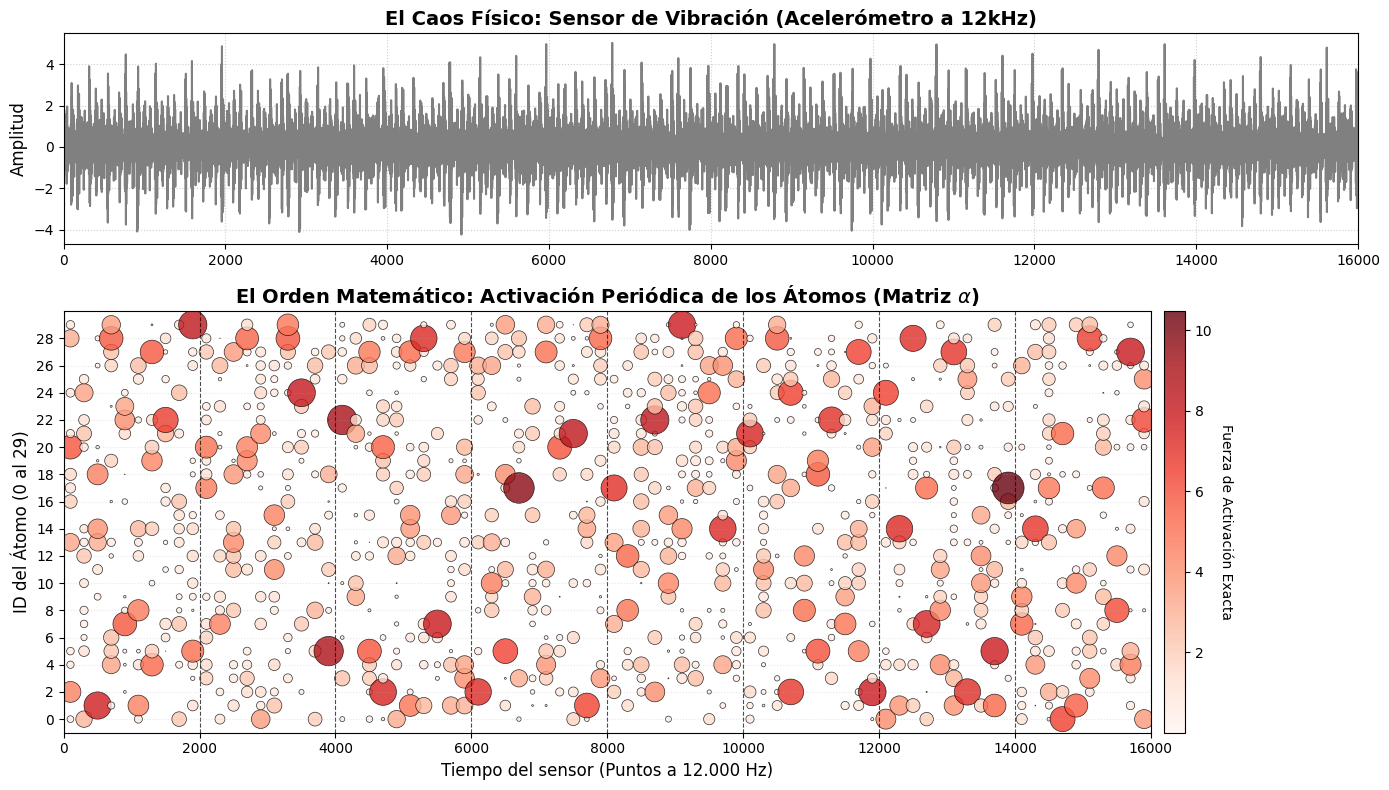

In [6]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import time
import sys
from sklearn.decomposition import DictionaryLearning
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1) CARGA DEL MOTOR ROTO (CWRU)
# ==========================================
print("Cargando el archivo CWRU real (Motor con fallo en pista interna)...")
archivo_local = "105.mat" 

try:
    mat_data = scipy.io.loadmat(archivo_local)
except FileNotFoundError:
    print(f"\n[ERROR] No encuentro el archivo '{archivo_local}'.")
    sys.exit()

clave_sensor = [key for key in mat_data.keys() if 'DE_time' in key][0]
senal_cruda = mat_data[clave_sensor].flatten()

# ==========================================
# 2) VENTANEO MATEMÁTICO
# ==========================================
longitud_ventana = 200
num_ventanas = len(senal_cruda) // longitud_ventana

X_vibracion = senal_cruda[:num_ventanas * longitud_ventana].reshape(num_ventanas, longitud_ventana)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_vibracion)

# ==========================================
# 3) SPARSE CODING (EL TURBO MULTINÚCLEO)
# ==========================================
n_atoms = 30
lambda_param = 1.0

print(f"Extrayendo el vocabulario a máxima potencia con TODOS los núcleos...")
inicio_tiempo = time.time()

dict_learner = DictionaryLearning(
    n_components=n_atoms, 
    alpha=lambda_param, 
    transform_algorithm='lasso_lars', 
    random_state=42,
    max_iter=1000,
    n_jobs=-1  # <--- TU REGLA APLICADA SIEMPRE: 100% de los núcleos
)

sparse_representation = dict_learner.fit_transform(X_scaled)
dictionary_atoms = dict_learner.components_

print(f"Entrenamiento completado en {time.time() - inicio_tiempo:.2f} segundos.")

# ==========================================
# 4) AUDITORÍA PURA SIN RAÍCES
# ==========================================
X_reconstruido = np.dot(sparse_representation, dictionary_atoms)

# TU REGLA: Sumas al cuadrado exactas, matemáticas puras.
error_fidelidad = 0.5 * np.sum((X_scaled - X_reconstruido) ** 2)
penalizacion_L1 = lambda_param * np.sum(np.abs(sparse_representation))

print("\n" + "="*60)
print(" AUDITORÍA MATEMÁTICA EXACTA")
print("="*60)
print(f" -> Fidelidad (Error Puro):         {error_fidelidad:.4f}")
print(f" -> Castigo L1 (Esparcidad):        {penalizacion_L1:.4f}")
print("="*60 + "\n")

# ==========================================
# 5) VISUALIZACIÓN DEL "METRÓNOMO" METÁLICO
# ==========================================
print("Generando el electrocardiógrama del motor (Partitura de Átomos)...")

# Vamos a ver solo un bloque de tiempo para que se vea claro el ritmo (ej. 80 ventanas)
ventanas_a_ver = 80 
tiempo_puntos = ventanas_a_ver * longitud_ventana

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [1, 2]})

# --- PANEL SUPERIOR: LA SEÑAL CRUDA ---
# Pintamos las ventanas seguidas para ver la onda continua
ax1.plot(X_scaled[:ventanas_a_ver].flatten(), color='gray', linewidth=1.5, label='Vibración Cruda (Ruido + Golpes)')
ax1.set_title('El Caos Físico: Sensor de Vibración (Acelerómetro a 12kHz)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Amplitud', fontsize=12)
ax1.set_xlim(0, tiempo_puntos)
ax1.grid(True, linestyle=':', alpha=0.6)

# --- PANEL INFERIOR: LA PARTITURA SPARSE (EL METRÓNOMO) ---
# Extraemos los coeficientes alfa de esas ventanas concretas
alfa_zoom = sparse_representation[:ventanas_a_ver, :]

# Buscamos qué átomos están encendidos y con qué fuerza
ventanas_encendidas, atomos_encendidos = np.nonzero(alfa_zoom)
fuerzas = np.abs(alfa_zoom[ventanas_encendidas, atomos_encendidos])

# Dibujamos un "Scatter" donde X es el tiempo e Y es el átomo.
# Ajustamos la X multiplicando por la longitud de la ventana para que se alinee perfectamente con la gráfica de arriba.
x_tiempo_alineado = ventanas_encendidas * longitud_ventana + (longitud_ventana // 2)

scatter = ax2.scatter(x_tiempo_alineado, atomos_encendidos, s=fuerzas * 50, c=fuerzas, 
                      cmap='Reds', alpha=0.8, edgecolor='black', linewidth=0.5)

ax2.set_title('El Orden Matemático: Activación Periódica de los Átomos (Matriz $\\alpha$)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Tiempo del sensor (Puntos a 12.000 Hz)', fontsize=12)
ax2.set_ylabel('ID del Átomo (0 al 29)', fontsize=12)
ax2.set_yticks(np.arange(0, 30, 2))
ax2.set_ylim(-1, n_atoms)
ax2.set_xlim(0, tiempo_puntos)
ax2.grid(True, axis='x', linestyle='--', alpha=0.7, color='black') # Rejilla vertical para marcar el metrónomo
ax2.grid(True, axis='y', linestyle=':', alpha=0.3)

# Añadimos barra de color para indicar la fuerza del impacto
cbar = plt.colorbar(scatter, ax=ax2, pad=0.01)
cbar.set_label('Fuerza de Activación Exacta', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

Cargando el archivo CWRU real (Motor con fallo en pista interna)...
Extrayendo el vocabulario a máxima potencia con TODOS los núcleos...
Entrenamiento completado en 4.93 segundos.

 AUDITORÍA MATEMÁTICA EXACTA
 -> Fidelidad (Error Puro):         35980.6189
 -> Castigo L1 (Esparcidad):        13081.8490

Generando el electrocardiógrama del motor (Partitura de Átomos)...


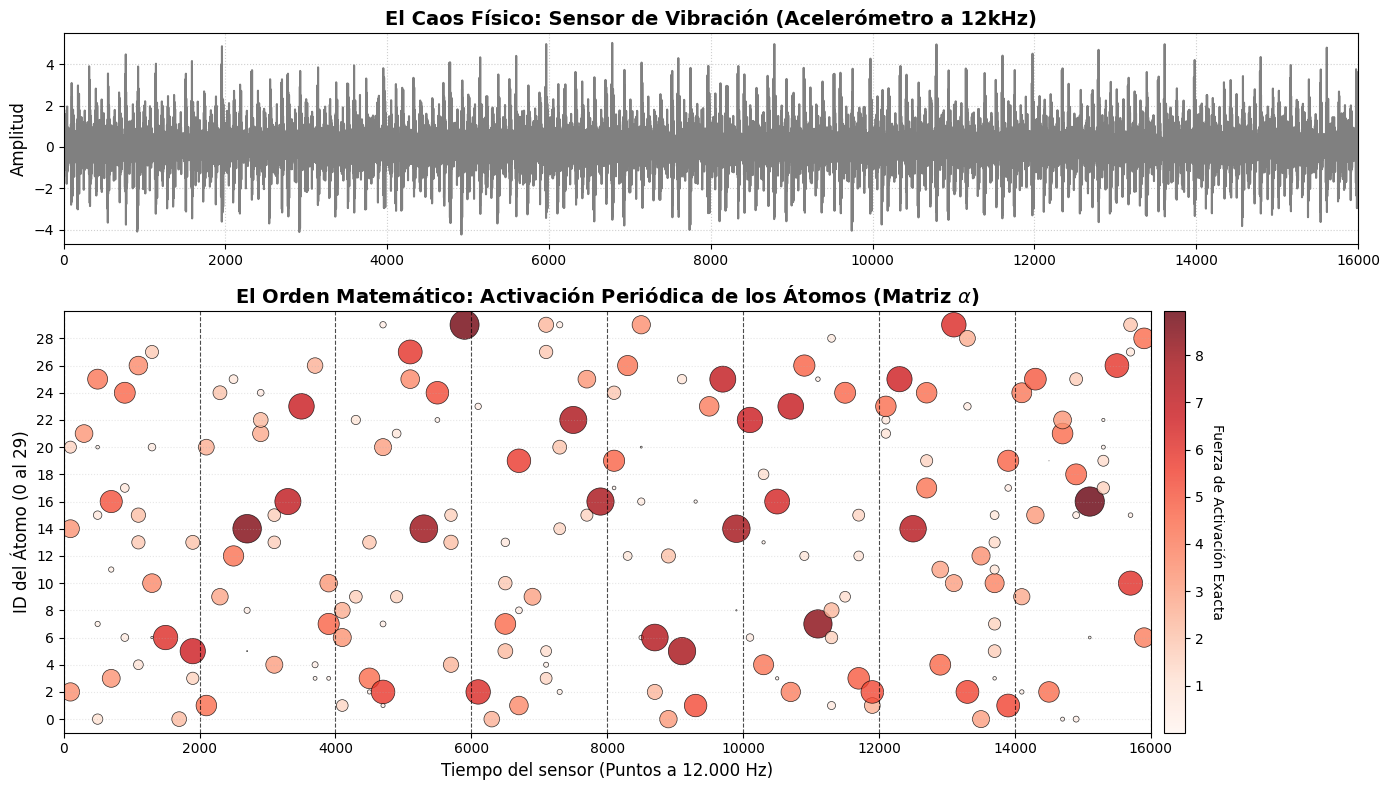

In [11]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import time
import sys
from sklearn.decomposition import DictionaryLearning
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1) CARGA DEL MOTOR ROTO (CWRU)
# ==========================================
print("Cargando el archivo CWRU real (Motor con fallo en pista interna)...")
archivo_local = "105.mat" 

try:
    mat_data = scipy.io.loadmat(archivo_local)
except FileNotFoundError:
    print(f"\n[ERROR] No encuentro el archivo '{archivo_local}'.")
    sys.exit()

clave_sensor = [key for key in mat_data.keys() if 'DE_time' in key][0]
senal_cruda = mat_data[clave_sensor].flatten()

# ==========================================
# 2) VENTANEO MATEMÁTICO
# ==========================================
longitud_ventana = 200
num_ventanas = len(senal_cruda) // longitud_ventana

X_vibracion = senal_cruda[:num_ventanas * longitud_ventana].reshape(num_ventanas, longitud_ventana)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_vibracion)

# ==========================================
# 3) SPARSE CODING (EL TURBO MULTINÚCLEO)
# ==========================================
n_atoms = 30
lambda_param = 3.0

print(f"Extrayendo el vocabulario a máxima potencia con TODOS los núcleos...")
inicio_tiempo = time.time()

dict_learner = DictionaryLearning(
    n_components=n_atoms, 
    alpha=lambda_param, 
    transform_algorithm='lasso_lars', 
    random_state=42,
    max_iter=1000,
    n_jobs=-1  # <--- TU REGLA APLICADA SIEMPRE: 100% de los núcleos
)

sparse_representation = dict_learner.fit_transform(X_scaled)
dictionary_atoms = dict_learner.components_

print(f"Entrenamiento completado en {time.time() - inicio_tiempo:.2f} segundos.")

# ==========================================
# 4) AUDITORÍA PURA SIN RAÍCES
# ==========================================
X_reconstruido = np.dot(sparse_representation, dictionary_atoms)

# TU REGLA: Sumas al cuadrado exactas, matemáticas puras.
error_fidelidad = 0.5 * np.sum((X_scaled - X_reconstruido) ** 2)
penalizacion_L1 = lambda_param * np.sum(np.abs(sparse_representation))

print("\n" + "="*60)
print(" AUDITORÍA MATEMÁTICA EXACTA")
print("="*60)
print(f" -> Fidelidad (Error Puro):         {error_fidelidad:.4f}")
print(f" -> Castigo L1 (Esparcidad):        {penalizacion_L1:.4f}")
print("="*60 + "\n")

# ==========================================
# 5) VISUALIZACIÓN DEL "METRÓNOMO" METÁLICO
# ==========================================
print("Generando el electrocardiógrama del motor (Partitura de Átomos)...")

# Vamos a ver solo un bloque de tiempo para que se vea claro el ritmo (ej. 80 ventanas)
ventanas_a_ver = 80 
tiempo_puntos = ventanas_a_ver * longitud_ventana

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [1, 2]})

# --- PANEL SUPERIOR: LA SEÑAL CRUDA ---
# Pintamos las ventanas seguidas para ver la onda continua
ax1.plot(X_scaled[:ventanas_a_ver].flatten(), color='gray', linewidth=1.5, label='Vibración Cruda (Ruido + Golpes)')
ax1.set_title('El Caos Físico: Sensor de Vibración (Acelerómetro a 12kHz)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Amplitud', fontsize=12)
ax1.set_xlim(0, tiempo_puntos)
ax1.grid(True, linestyle=':', alpha=0.6)

# --- PANEL INFERIOR: LA PARTITURA SPARSE (EL METRÓNOMO) ---
# Extraemos los coeficientes alfa de esas ventanas concretas
alfa_zoom = sparse_representation[:ventanas_a_ver, :]

# Buscamos qué átomos están encendidos y con qué fuerza
ventanas_encendidas, atomos_encendidos = np.nonzero(alfa_zoom)
fuerzas = np.abs(alfa_zoom[ventanas_encendidas, atomos_encendidos])

# Dibujamos un "Scatter" donde X es el tiempo e Y es el átomo.
# Ajustamos la X multiplicando por la longitud de la ventana para que se alinee perfectamente con la gráfica de arriba.
x_tiempo_alineado = ventanas_encendidas * longitud_ventana + (longitud_ventana // 2)

scatter = ax2.scatter(x_tiempo_alineado, atomos_encendidos, s=fuerzas * 50, c=fuerzas, 
                      cmap='Reds', alpha=0.8, edgecolor='black', linewidth=0.5)

ax2.set_title('El Orden Matemático: Activación Periódica de los Átomos (Matriz $\\alpha$)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Tiempo del sensor (Puntos a 12.000 Hz)', fontsize=12)
ax2.set_ylabel('ID del Átomo (0 al 29)', fontsize=12)
ax2.set_yticks(np.arange(0, 30, 2))
ax2.set_ylim(-1, n_atoms)
ax2.set_xlim(0, tiempo_puntos)
ax2.grid(True, axis='x', linestyle='--', alpha=0.7, color='black') # Rejilla vertical para marcar el metrónomo
ax2.grid(True, axis='y', linestyle=':', alpha=0.3)

# Añadimos barra de color para indicar la fuerza del impacto
cbar = plt.colorbar(scatter, ax=ax2, pad=0.01)
cbar.set_label('Fuerza de Activación Exacta', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

Cargando el archivo CWRU real (Motor con fallo en pista interna)...
Extrayendo el vocabulario a máxima potencia con TODOS los núcleos...
Entrenamiento completado en 4.22 segundos.

 AUDITORÍA MATEMÁTICA EXACTA
 -> Fidelidad (Error Puro):         40666.9648
 -> Castigo L1 (Esparcidad):        12069.0429

Generando el electrocardiógrama del motor (Partitura de Átomos)...


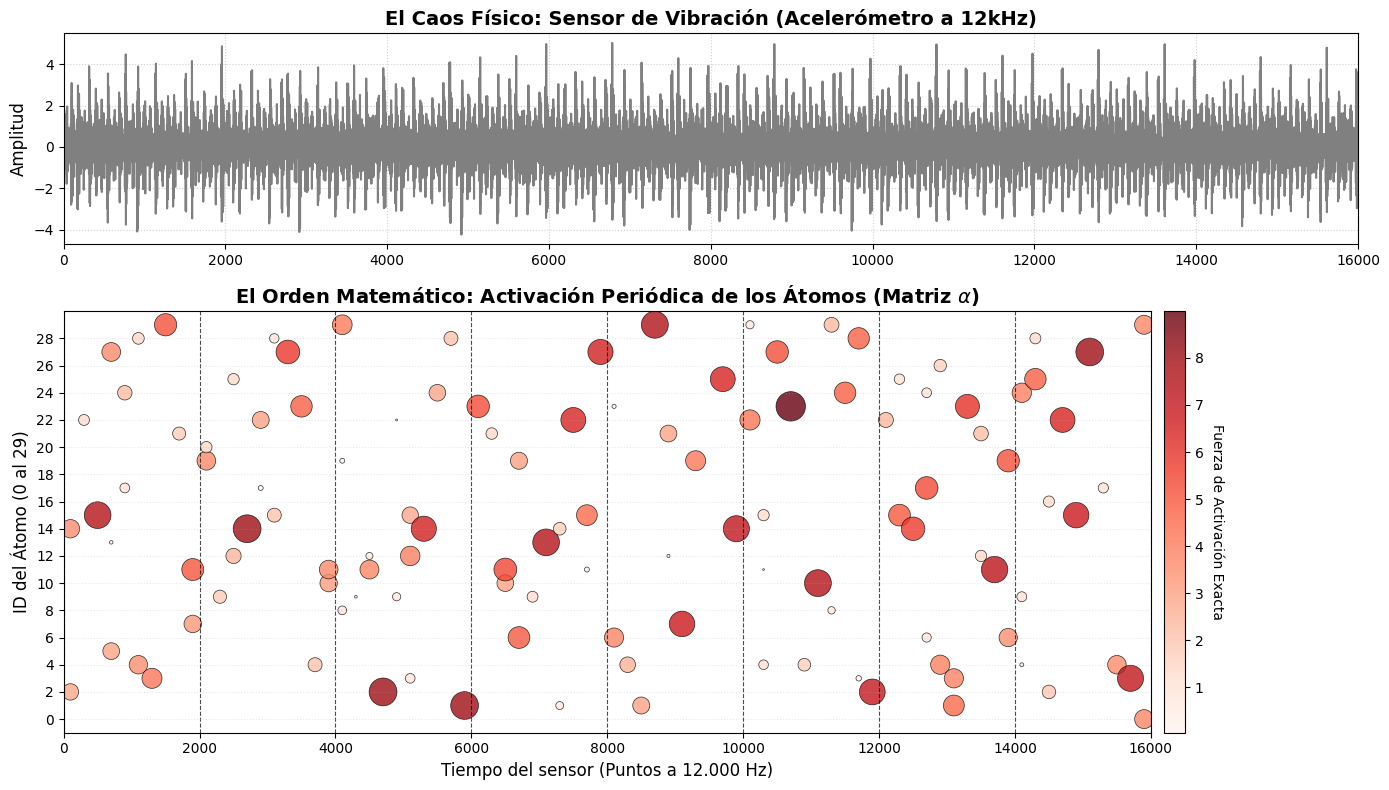

In [12]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import time
import sys
from sklearn.decomposition import DictionaryLearning
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1) CARGA DEL MOTOR ROTO (CWRU)
# ==========================================
print("Cargando el archivo CWRU real (Motor con fallo en pista interna)...")
archivo_local = "105.mat" 

try:
    mat_data = scipy.io.loadmat(archivo_local)
except FileNotFoundError:
    print(f"\n[ERROR] No encuentro el archivo '{archivo_local}'.")
    sys.exit()

clave_sensor = [key for key in mat_data.keys() if 'DE_time' in key][0]
senal_cruda = mat_data[clave_sensor].flatten()

# ==========================================
# 2) VENTANEO MATEMÁTICO
# ==========================================
longitud_ventana = 200
num_ventanas = len(senal_cruda) // longitud_ventana

X_vibracion = senal_cruda[:num_ventanas * longitud_ventana].reshape(num_ventanas, longitud_ventana)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_vibracion)

# ==========================================
# 3) SPARSE CODING (EL TURBO MULTINÚCLEO)
# ==========================================
n_atoms = 30
lambda_param = 4.0

print(f"Extrayendo el vocabulario a máxima potencia con TODOS los núcleos...")
inicio_tiempo = time.time()

dict_learner = DictionaryLearning(
    n_components=n_atoms, 
    alpha=lambda_param, 
    transform_algorithm='lasso_lars', 
    random_state=42,
    max_iter=1000,
    n_jobs=-1  # <--- TU REGLA APLICADA SIEMPRE: 100% de los núcleos
)

sparse_representation = dict_learner.fit_transform(X_scaled)
dictionary_atoms = dict_learner.components_

print(f"Entrenamiento completado en {time.time() - inicio_tiempo:.2f} segundos.")

# ==========================================
# 4) AUDITORÍA PURA SIN RAÍCES
# ==========================================
X_reconstruido = np.dot(sparse_representation, dictionary_atoms)

# TU REGLA: Sumas al cuadrado exactas, matemáticas puras.
error_fidelidad = 0.5 * np.sum((X_scaled - X_reconstruido) ** 2)
penalizacion_L1 = lambda_param * np.sum(np.abs(sparse_representation))

print("\n" + "="*60)
print(" AUDITORÍA MATEMÁTICA EXACTA")
print("="*60)
print(f" -> Fidelidad (Error Puro):         {error_fidelidad:.4f}")
print(f" -> Castigo L1 (Esparcidad):        {penalizacion_L1:.4f}")
print("="*60 + "\n")

# ==========================================
# 5) VISUALIZACIÓN DEL "METRÓNOMO" METÁLICO
# ==========================================
print("Generando el electrocardiógrama del motor (Partitura de Átomos)...")

# Vamos a ver solo un bloque de tiempo para que se vea claro el ritmo (ej. 80 ventanas)
ventanas_a_ver = 80 
tiempo_puntos = ventanas_a_ver * longitud_ventana

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [1, 2]})

# --- PANEL SUPERIOR: LA SEÑAL CRUDA ---
# Pintamos las ventanas seguidas para ver la onda continua
ax1.plot(X_scaled[:ventanas_a_ver].flatten(), color='gray', linewidth=1.5, label='Vibración Cruda (Ruido + Golpes)')
ax1.set_title('El Caos Físico: Sensor de Vibración (Acelerómetro a 12kHz)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Amplitud', fontsize=12)
ax1.set_xlim(0, tiempo_puntos)
ax1.grid(True, linestyle=':', alpha=0.6)

# --- PANEL INFERIOR: LA PARTITURA SPARSE (EL METRÓNOMO) ---
# Extraemos los coeficientes alfa de esas ventanas concretas
alfa_zoom = sparse_representation[:ventanas_a_ver, :]

# Buscamos qué átomos están encendidos y con qué fuerza
ventanas_encendidas, atomos_encendidos = np.nonzero(alfa_zoom)
fuerzas = np.abs(alfa_zoom[ventanas_encendidas, atomos_encendidos])

# Dibujamos un "Scatter" donde X es el tiempo e Y es el átomo.
# Ajustamos la X multiplicando por la longitud de la ventana para que se alinee perfectamente con la gráfica de arriba.
x_tiempo_alineado = ventanas_encendidas * longitud_ventana + (longitud_ventana // 2)

scatter = ax2.scatter(x_tiempo_alineado, atomos_encendidos, s=fuerzas * 50, c=fuerzas, 
                      cmap='Reds', alpha=0.8, edgecolor='black', linewidth=0.5)

ax2.set_title('El Orden Matemático: Activación Periódica de los Átomos (Matriz $\\alpha$)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Tiempo del sensor (Puntos a 12.000 Hz)', fontsize=12)
ax2.set_ylabel('ID del Átomo (0 al 29)', fontsize=12)
ax2.set_yticks(np.arange(0, 30, 2))
ax2.set_ylim(-1, n_atoms)
ax2.set_xlim(0, tiempo_puntos)
ax2.grid(True, axis='x', linestyle='--', alpha=0.7, color='black') # Rejilla vertical para marcar el metrónomo
ax2.grid(True, axis='y', linestyle=':', alpha=0.3)

# Añadimos barra de color para indicar la fuerza del impacto
cbar = plt.colorbar(scatter, ax=ax2, pad=0.01)
cbar.set_label('Fuerza de Activación Exacta', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

Generando señal de impactos de alta energía...
Procesando con todos los núcleos (Turbo-Sensibilidad)...


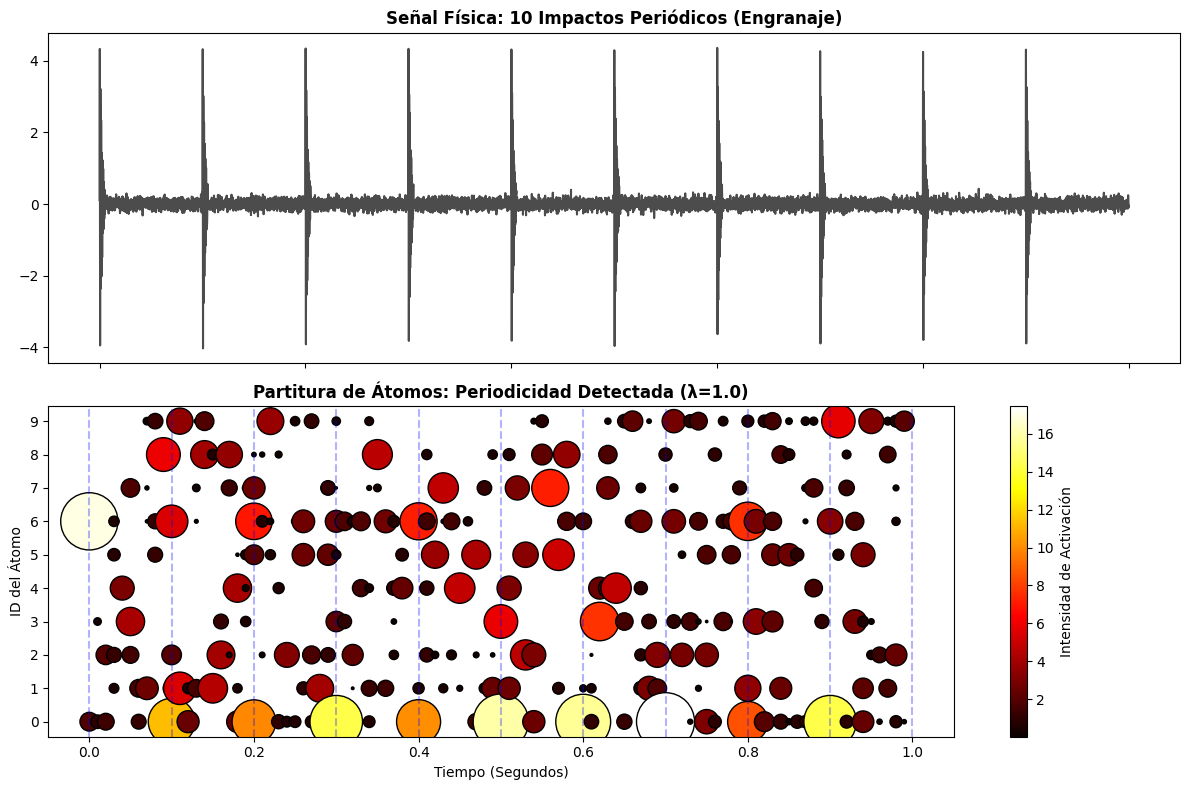

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.decomposition import DictionaryLearning
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1) GENERACIÓN DE IMPACTOS VIOLENTOS (METRÓNOMO)
# ==========================================
print("Generando señal de impactos de alta energía...")
fs = 10000
t = np.arange(0, 1.0, 1/fs)

# Creamos 10 impactos masivos (uno cada 0.1s)
senal = np.zeros_like(t)
for i in range(10):
    inicio = int(i * 0.1 * fs)
    # Impacto muy fuerte que destaca sobre cualquier ruido
    duracion_impacto = np.arange(0, 0.005, 1/fs)
    golpe = 5.0 * np.exp(-500 * duracion_impacto) * np.sin(2 * np.pi * 1500 * duracion_impacto)
    senal[inicio:inicio+len(golpe)] = golpe

# Añadimos un poco de ruido, pero muy poco para no tapar el patrón
senal += np.random.normal(0, 0.1, len(t))

# ==========================================
# 2) MATRIZ Y ESCALADO
# ==========================================
longitud_ventana = 100 # Ventanas más pequeñas para mayor resolución temporal
num_ventanas = len(senal) // longitud_ventana
X = senal[:num_ventanas * longitud_ventana].reshape(num_ventanas, longitud_ventana)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# 3) SPARSE CODING (HIPER-SENSIBLE)
# ==========================================
n_atoms = 10
# Bajamos lambda al mínimo para que el algoritmo SE VEA OBLIGADO a pintar
lambda_param = 1.0 

print(f"Procesando con todos los núcleos (Turbo-Sensibilidad)...")
dict_learner = DictionaryLearning(
    n_components=n_atoms, 
    alpha=lambda_param, 
    transform_algorithm='lasso_lars', 
    n_jobs=-1, # Máxima potencia
    random_state=42
)

sparse_rep = dict_learner.fit_transform(X_scaled)

# ==========================================
# 4) VISUALIZACIÓN DE ALTA INTENSIDAD
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Señal original
ax1.plot(np.linspace(0, 1, len(senal)), senal, color='black', alpha=0.7)
ax1.set_title("Señal Física: 10 Impactos Periódicos (Engranaje)", fontweight='bold')

# Mapa de activaciones (Metrónomo)
# Usamos s=100 para que los puntos sean GIGANTES
v, a = np.nonzero(sparse_rep)
fuerzas = np.abs(sparse_rep[v, a])
tiempos = v * (longitud_ventana / fs)

scatter = ax2.scatter(tiempos, a, s=fuerzas * 100, c=fuerzas, cmap='hot', edgecolors='black')
ax2.set_title(f"Partitura de Átomos: Periodicidad Detectada (λ={lambda_param})", fontweight='bold')
ax2.set_ylabel("ID del Átomo")
ax2.set_xlabel("Tiempo (Segundos)")
ax2.set_yticks(range(n_atoms))

# Marcamos las líneas de 0.1s para comprobar la precisión
for i in np.arange(0, 1.1, 0.1):
    ax2.axvline(i, color='blue', linestyle='--', alpha=0.3)

plt.colorbar(scatter, ax=ax2, label="Intensidad de Activación")
plt.tight_layout()
plt.show()